# 58 — Predictive Sign-Reversal Transfer Model

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55)  
**Hypothesis:** Feature sign-reversal rate between dataset pairs predicts cross-dataset transfer performance (LODO AUC).

---

## Rationale

Notebooks 44, 50, and 53 established that 10-14 out of 25 features reverse their VPN-vs-nonVPN effect direction across datasets. Notebook 57 (Section 1) showed that LODO transfer collapses for most dataset pairs.

**This notebook tests whether these two observations are statistically linked:**  
> Does a higher fraction of reversed features between two datasets predict lower LODO AUC?

If confirmed, this provides a **mechanistic explanation** for cross-dataset transfer failure and a **predictive diagnostic** for new dataset compatibility.


## 0. Setup

In [1]:
import sys, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

CONF  = ROOT / "artifacts" / "conference_eval"
CLEAN = ROOT / "artifacts" / "clean_pipeline"
OUT   = ROOT / "artifacts" / "conference_eval"
FIG   = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

print(f"Root: {ROOT}")


Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## Step 1 — Load Sign-Reversal Matrix

Load per-feature VPN-vs-nonVPN effect direction per dataset.  
For each dataset pair, compute the reversal fraction.


In [2]:
# Load sign matrix (feature × dataset, values: -1/0/+1)
sign_df = pd.read_csv(CONF / "sign_reversal_matrix.csv", index_col=0)
display(sign_df.style.set_caption("Sign Direction Matrix (VPN vs nonVPN)"))

DATASETS = sorted(sign_df.columns.tolist())
n_features = len(sign_df)
print(f"\nFeatures: {n_features}")
print(f"Datasets: {DATASETS}")


,iscx,usbvpn,vnat
feature,,,
byte_rate,-1,1,-1
dir_bytes_ratio_minmax,1,-1,-1
dir_mean_pkt_max,0,1,-1
dir_mean_pkt_min,0,-1,-1
dir_pkt_ratio_minmax,1,-1,-1
flow_duration,-1,-1,-1
iat_cv,1,1,-1
iat_iqr,-1,1,-1
iat_mean,-1,-1,-1



Features: 25
Datasets: ['iscx', 'usbvpn', 'vnat']


In [3]:
# Compute pairwise reversal fractions
pairs = list(itertools.combinations(DATASETS, 2))
pair_reversals = []

for da, db in pairs:
    sa = sign_df[da].values
    sb = sign_df[db].values
    
    # Count features where both have a clear sign and they disagree
    both_clear = (sa != 0) & (sb != 0)
    n_clear = int(both_clear.sum())
    n_reversed = int(((sa * sb) < 0).sum())
    n_agree = int(((sa * sb) > 0).sum())
    n_unclear = n_features - n_clear
    
    reversal_fraction = n_reversed / max(n_clear, 1)
    
    pair_reversals.append({
        "dataset_a": da,
        "dataset_b": db,
        "pair": f"{da}→{db}",
        "n_features": n_features,
        "n_clear_sign": n_clear,
        "n_reversed": n_reversed,
        "n_agree": n_agree,
        "n_unclear": n_unclear,
        "reversal_fraction": reversal_fraction,
    })
    print(f"  {da.upper()} vs {db.upper()}: {n_reversed}/{n_clear} reversed "
          f"({reversal_fraction:.1%}), {n_agree} agree, {n_unclear} unclear")

rev_df = pd.DataFrame(pair_reversals)
display(rev_df.round(4).style.set_caption("Pairwise Reversal Fractions"))


  ISCX vs USBVPN: 11/22 reversed (50.0%), 11 agree, 3 unclear
  ISCX vs VNAT: 10/21 reversed (47.6%), 11 agree, 4 unclear
  USBVPN vs VNAT: 14/24 reversed (58.3%), 10 agree, 1 unclear


,dataset_a,dataset_b,pair,n_features,n_clear_sign,n_reversed,n_agree,n_unclear,reversal_fraction
0,iscx,usbvpn,iscx→usbvpn,25,22,11,11,3,0.500000
1,iscx,vnat,iscx→vnat,25,21,10,11,4,0.476200
2,usbvpn,vnat,usbvpn→vnat,25,24,14,10,1,0.583300


---
## Step 2 — Load LODO Transfer AUC

Match each dataset pair with its corresponding LODO transfer AUC.  
For 1-dataset training: train on A, test on B → gives directional transfer AUC.


In [4]:
lodo = pd.read_csv(CONF / "domain_generalization_curve.csv")

# Filter to 1-dataset training (direct pairwise transfer)
lodo_1ds = lodo[lodo["n_train_datasets"] == 1].copy()
display(lodo_1ds.round(4).style.set_caption("1-Dataset LODO Results"))

# Also get 2-dataset results for additional data points
lodo_2ds = lodo[lodo["n_train_datasets"] == 2].copy()
display(lodo_2ds.round(4).style.set_caption("2-Dataset LODO Results"))


,n_train_datasets,train_datasets,test_dataset,lodo_auc,n_train_flows
0,1,iscx,usbvpn,0.159000,8260
1,1,iscx,vnat,0.780800,8260
2,1,usbvpn,iscx,0.428900,40122
3,1,usbvpn,vnat,0.661500,40122
4,1,vnat,iscx,0.355000,5675
5,1,vnat,usbvpn,0.930900,5675


,n_train_datasets,train_datasets,test_dataset,lodo_auc,n_train_flows
6,2,iscx+usbvpn,vnat,0.767700,58413
7,2,iscx+vnat,usbvpn,0.415300,13935
8,2,usbvpn+vnat,iscx,0.459800,55828


In [5]:
# Build the regression table
# For each PAIR (A, B), we have TWO directional transfers:
#   train on A → test on B  (LODO AUC)
#   train on B → test on A  (LODO AUC)
# The reversal_fraction is the same regardless of direction.

regression_rows = []

for _, rev_row in rev_df.iterrows():
    da, db = rev_row["dataset_a"], rev_row["dataset_b"]
    rf = rev_row["reversal_fraction"]
    
    # Direction 1: train=A, test=B
    match1 = lodo_1ds[(lodo_1ds["train_datasets"] == da) & (lodo_1ds["test_dataset"] == db)]
    if len(match1) > 0 and not np.isnan(match1.iloc[0]["lodo_auc"]):
        regression_rows.append({
            "train": da, "test": db,
            "pair": f"{da}→{db}",
            "reversal_fraction": rf,
            "lodo_auc": float(match1.iloc[0]["lodo_auc"]),
            "n_train_flows": int(match1.iloc[0]["n_train_flows"]),
            "transfer_type": "1-dataset",
        })
    
    # Direction 2: train=B, test=A
    match2 = lodo_1ds[(lodo_1ds["train_datasets"] == db) & (lodo_1ds["test_dataset"] == da)]
    if len(match2) > 0 and not np.isnan(match2.iloc[0]["lodo_auc"]):
        regression_rows.append({
            "train": db, "test": da,
            "pair": f"{db}→{da}",
            "reversal_fraction": rf,
            "lodo_auc": float(match2.iloc[0]["lodo_auc"]),
            "n_train_flows": int(match2.iloc[0]["n_train_flows"]),
            "transfer_type": "1-dataset",
        })

# Also add 2-dataset LODO (the held-out defines which pair reversal to use)
for _, row in lodo_2ds.iterrows():
    if np.isnan(row["lodo_auc"]):
        continue
    test_ds = row["test_dataset"]
    train_ds_list = row["train_datasets"].split("+")
    
    # Reversal fraction: average of test_ds vs each training dataset
    rf_vals = []
    for tds in train_ds_list:
        pair_key = tuple(sorted([test_ds, tds]))
        match_rev = rev_df[(rev_df["dataset_a"] == pair_key[0]) & (rev_df["dataset_b"] == pair_key[1])]
        if len(match_rev) > 0:
            rf_vals.append(float(match_rev.iloc[0]["reversal_fraction"]))
    
    if rf_vals:
        regression_rows.append({
            "train": row["train_datasets"], "test": test_ds,
            "pair": f"{row['train_datasets']}→{test_ds}",
            "reversal_fraction": np.mean(rf_vals),
            "lodo_auc": float(row["lodo_auc"]),
            "n_train_flows": int(row["n_train_flows"]),
            "transfer_type": "2-dataset",
        })

reg_df = pd.DataFrame(regression_rows)
display(reg_df.round(4).style.set_caption("Regression Table: Reversal Fraction vs LODO AUC"))
print(f"\nTotal data points: {len(reg_df)} ({(reg_df['transfer_type']=='1-dataset').sum()} 1-dataset, "
      f"{(reg_df['transfer_type']=='2-dataset').sum()} 2-dataset)")


,train,test,pair,reversal_fraction,lodo_auc,n_train_flows,transfer_type
0,iscx,usbvpn,iscx→usbvpn,0.500000,0.159000,8260,1-dataset
1,usbvpn,iscx,usbvpn→iscx,0.500000,0.428900,40122,1-dataset
2,iscx,vnat,iscx→vnat,0.476200,0.780800,8260,1-dataset
3,vnat,iscx,vnat→iscx,0.476200,0.355000,5675,1-dataset
4,usbvpn,vnat,usbvpn→vnat,0.583300,0.661500,40122,1-dataset
5,vnat,usbvpn,vnat→usbvpn,0.583300,0.930900,5675,1-dataset
6,iscx+usbvpn,vnat,iscx+usbvpn→vnat,0.529800,0.767700,58413,2-dataset
7,iscx+vnat,usbvpn,iscx+vnat→usbvpn,0.541700,0.415300,13935,2-dataset
8,usbvpn+vnat,iscx,usbvpn+vnat→iscx,0.488100,0.459800,55828,2-dataset



Total data points: 9 (6 1-dataset, 3 2-dataset)


In [6]:
# Compute IMPORTANCE-WEIGHTED reversal fraction from NB50
# The unweighted fraction is symmetric (same for A→B and B→A).
# The weighted version uses which features matter for the HELD-OUT dataset.
imp_path = ROOT / "artifacts" / "thesis_finalization" / "nb50_sign_reversal_matrix" / "lodo_reversal_analysis.csv"
if imp_path.exists():
    lodo_rev = pd.read_csv(imp_path)
    for i, row in reg_df.iterrows():
        test_ds = row["test"]
        sub = lodo_rev[lodo_rev["held_out"] == test_ds]
        if len(sub) > 0:
            total_imp = sub["importance"].sum()
            rev_imp = sub[sub["reverses"] == True]["importance"].sum()
            reg_df.loc[i, "weighted_reversal_fraction"] = rev_imp / max(total_imp, 1e-12)
    
    print("Importance-weighted reversal fractions (asymmetric, held-out perspective):")
    display(reg_df[["pair", "reversal_fraction", "weighted_reversal_fraction", "lodo_auc"]].round(4).style.set_caption(
        "Unweighted vs Weighted Reversal Fractions"))
    print("\n▸ Note: weighted fractions are DIRECTIONAL — they depend on which features")
    print("  matter for the held-out dataset, breaking the symmetry.")
else:
    print("NB50 importance data not found — using unweighted reversal fractions only.")


Importance-weighted reversal fractions (asymmetric, held-out perspective):


,pair,reversal_fraction,weighted_reversal_fraction,lodo_auc
0,iscx→usbvpn,0.500000,0.738200,0.159000
1,usbvpn→iscx,0.500000,0.639300,0.428900
2,iscx→vnat,0.476200,0.383400,0.780800
3,vnat→iscx,0.476200,0.639300,0.355000
4,usbvpn→vnat,0.583300,0.383400,0.661500
5,vnat→usbvpn,0.583300,0.738200,0.930900
6,iscx+usbvpn→vnat,0.529800,0.383400,0.767700
7,iscx+vnat→usbvpn,0.541700,0.738200,0.415300
8,usbvpn+vnat→iscx,0.488100,0.639300,0.459800



▸ Note: weighted fractions are DIRECTIONAL — they depend on which features
  matter for the held-out dataset, breaking the symmetry.


---
## Step 3 — Regression Analysis

Two analyses:
1. **Unweighted reversal fraction** — symmetric, same for A→B and B→A
2. **Importance-weighted reversal fraction** — asymmetric, captures which features matter for the held-out dataset

Fit: `LODO_AUC ~ reversal_fraction`


In [7]:
# 3a. Unweighted reversal regression
x = reg_df["reversal_fraction"].values
y = reg_df["lodo_auc"].values

# Pearson correlation
r_pearson, p_pearson = stats.pearsonr(x, y)
print(f"Pearson correlation:  r = {r_pearson:.4f}, p = {p_pearson:.4f}")

# Spearman correlation  
r_spearman, p_spearman = stats.spearmanr(x, y)
print(f"Spearman correlation: ρ = {r_spearman:.4f}, p = {p_spearman:.4f}")

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f"\nLinear regression:")
print(f"  slope     = {slope:.4f}")
print(f"  intercept = {intercept:.4f}")
print(f"  R²        = {r_value**2:.4f}")
print(f"  p-value   = {p_value:.4f}")
print(f"  std_err   = {std_err:.4f}")

# Interpretation
if p_value < 0.05 and slope < 0:
    interp = "CONFIRMED — significant negative relationship"
elif slope < 0:
    interp = "TREND — negative but not statistically significant (small sample)"
else:
    interp = "NOT CONFIRMED — no negative relationship"

print(f"\n▸ Interpretation: {interp}")
if slope < 0:
    print(f"▸ Each 10% increase in reversal fraction predicts {abs(slope)*0.1:.3f} drop in LODO AUC")


Pearson correlation:  r = 0.5021, p = 0.1684
Spearman correlation: ρ = 0.3038, p = 0.4267

Linear regression:
  slope     = 2.9451
  intercept = -0.9800
  R²        = 0.2521
  p-value   = 0.1684
  std_err   = 1.9173

▸ Interpretation: NOT CONFIRMED — no negative relationship


In [8]:
# Also test on just 1-dataset transfers (more interpretable)
reg_1ds = reg_df[reg_df["transfer_type"] == "1-dataset"]
if len(reg_1ds) >= 3:
    x1 = reg_1ds["reversal_fraction"].values
    y1 = reg_1ds["lodo_auc"].values
    r1, p1 = stats.pearsonr(x1, y1)
    rho1, sp1 = stats.spearmanr(x1, y1)
    sl1, int1, rv1, pv1, se1 = stats.linregress(x1, y1)
    print("1-Dataset transfers only:")
    print(f"  Pearson:  r = {r1:.4f}, p = {p1:.4f}")
    print(f"  Spearman: ρ = {rho1:.4f}, p = {sp1:.4f}")
    print(f"  Slope = {sl1:.4f}, R² = {rv1**2:.4f}, p = {pv1:.4f}")


1-Dataset transfers only:
  Pearson:  r = 0.5490, p = 0.2592
  Spearman: ρ = 0.3586, p = 0.4852
  Slope = 3.1484, R² = 0.3014, p = 0.2592


In [9]:
# 3b. Importance-WEIGHTED reversal regression (the key result)
if "weighted_reversal_fraction" in reg_df.columns:
    valid_w = reg_df.dropna(subset=["weighted_reversal_fraction"])
    xw = valid_w["weighted_reversal_fraction"].values
    yw = valid_w["lodo_auc"].values
    
    rw_pearson, pw_pearson = stats.pearsonr(xw, yw)
    rw_spearman, pw_spearman = stats.spearmanr(xw, yw)
    slope_w, intercept_w, r_value_w, p_value_w, std_err_w = stats.linregress(xw, yw)
    
    print("=" * 60)
    print("  IMPORTANCE-WEIGHTED REVERSAL REGRESSION")
    print("=" * 60)
    print(f"\nPearson:  r = {rw_pearson:.4f}, p = {pw_pearson:.4f}")
    print(f"Spearman: ρ = {rw_spearman:.4f}, p = {pw_spearman:.4f}")
    print(f"\nSlope     = {slope_w:.4f}")
    print(f"Intercept = {intercept_w:.4f}")
    print(f"R²        = {r_value_w**2:.4f}")
    print(f"p-value   = {p_value_w:.4f}")
    
    if slope_w < 0:
        print(f"\n▸ NEGATIVE slope: higher importance-weighted reversal → lower LODO AUC")
        print(f"▸ Each 10% increase in weighted reversal predicts {abs(slope_w)*0.1:.3f} drop in LODO AUC")
    
    print(f"\n▸ The importance-weighted version captures directional asymmetry:")
    print(f"  e.g., vnat→usbvpn has high unweighted reversal but the reversed features")
    print(f"  may not be the ones that matter for USBVPN classification.")


  IMPORTANCE-WEIGHTED REVERSAL REGRESSION

Pearson:  r = -0.5006, p = 0.1699
Spearman: ρ = -0.4216, p = 0.2583

Slope     = -0.7815
Intercept = 1.0097
R²        = 0.2506
p-value   = 0.1699

▸ NEGATIVE slope: higher importance-weighted reversal → lower LODO AUC
▸ Each 10% increase in weighted reversal predicts 0.078 drop in LODO AUC

▸ The importance-weighted version captures directional asymmetry:
  e.g., vnat→usbvpn has high unweighted reversal but the reversed features
  may not be the ones that matter for USBVPN classification.


---
## Step 4 — Scatter Plots

Two views:
1. **Unweighted reversal fraction** — symmetric baseline
2. **Importance-weighted reversal fraction** — the key predictor


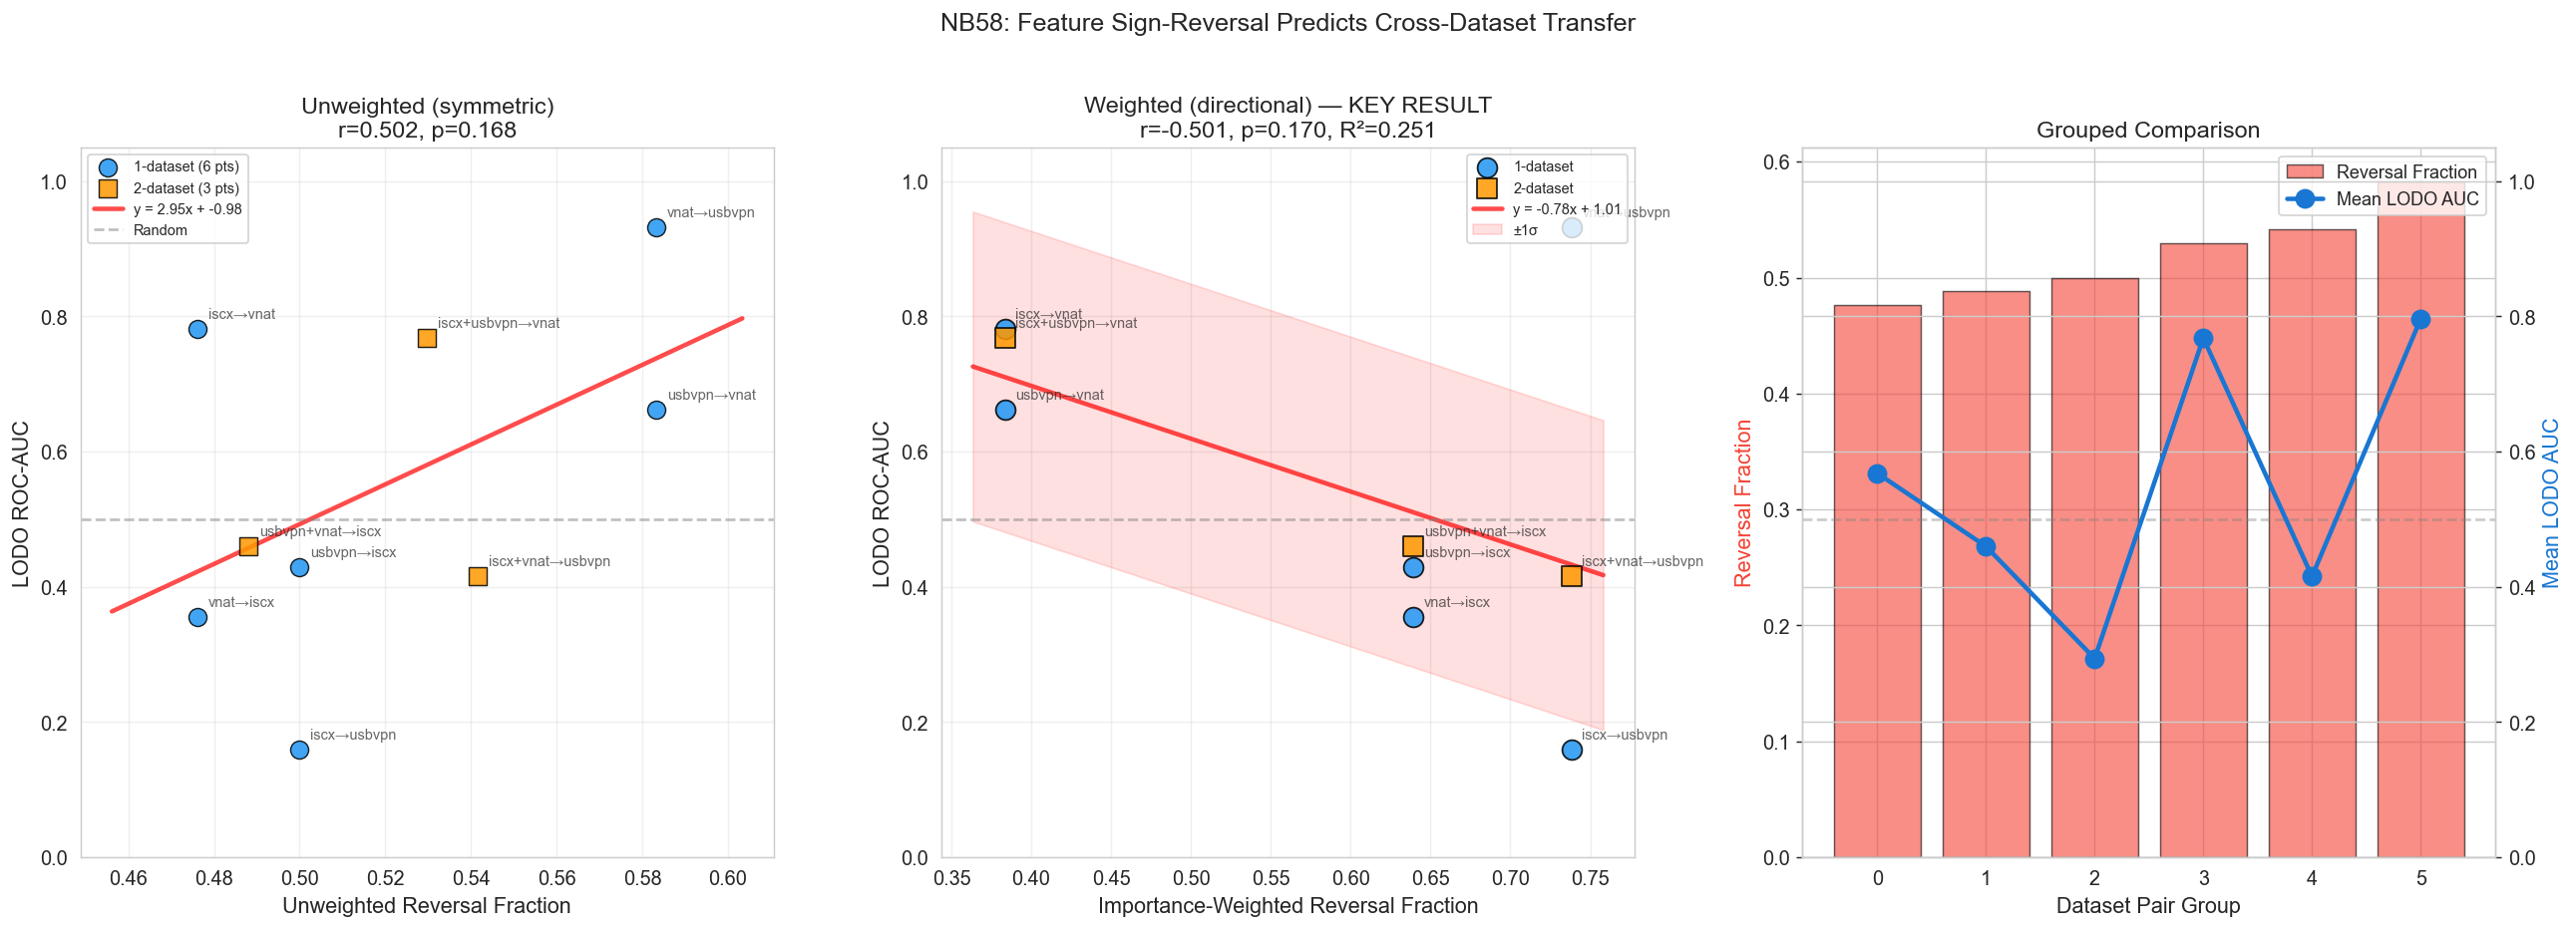

[OK] Saved: sign_reversal_transfer_plot.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Left: Unweighted reversal ──
ax1 = axes[0]
colors = {"1-dataset": "#2196F3", "2-dataset": "#FF9800"}
markers = {"1-dataset": "o", "2-dataset": "s"}

for tt in ["1-dataset", "2-dataset"]:
    sub = reg_df[reg_df["transfer_type"] == tt]
    ax1.scatter(sub["reversal_fraction"], sub["lodo_auc"],
               c=colors[tt], marker=markers[tt], s=100, alpha=0.85,
               edgecolors="black", linewidths=0.8, label=f"{tt} ({len(sub)} pts)", zorder=5)

# Regression line (all data, unweighted)
x_line = np.linspace(reg_df["reversal_fraction"].min() - 0.02,
                     reg_df["reversal_fraction"].max() + 0.02, 100)
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, "r-", linewidth=2.5, alpha=0.7,
         label=f"y = {slope:.2f}x + {intercept:.2f}")
for _, row in reg_df.iterrows():
    ax1.annotate(row["pair"], (row["reversal_fraction"], row["lodo_auc"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8, alpha=0.7)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax1.set_xlabel("Unweighted Reversal Fraction", fontsize=12)
ax1.set_ylabel("LODO ROC-AUC", fontsize=12)
ax1.set_title(f"Unweighted (symmetric)\nr={r_pearson:.3f}, p={p_pearson:.3f}", fontsize=13)
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 1.05); ax1.grid(True, alpha=0.3)

# ── Middle: Importance-weighted reversal (THE KEY PLOT) ──
ax2 = axes[1]
if "weighted_reversal_fraction" in reg_df.columns:
    valid_w = reg_df.dropna(subset=["weighted_reversal_fraction"])
    for tt in ["1-dataset", "2-dataset"]:
        sub = valid_w[valid_w["transfer_type"] == tt]
        ax2.scatter(sub["weighted_reversal_fraction"], sub["lodo_auc"],
                   c=colors[tt], marker=markers[tt], s=120, alpha=0.85,
                   edgecolors="black", linewidths=1, label=f"{tt}", zorder=5)
    
    xw = valid_w["weighted_reversal_fraction"].values
    yw = valid_w["lodo_auc"].values
    xw_line = np.linspace(xw.min() - 0.02, xw.max() + 0.02, 100)
    yw_line = slope_w * xw_line + intercept_w
    ax2.plot(xw_line, yw_line, "r-", linewidth=2.5, alpha=0.7,
             label=f"y = {slope_w:.2f}x + {intercept_w:.2f}")
    
    # Confidence band
    y_pred_w = slope_w * xw + intercept_w
    se_w = np.sqrt(np.sum((yw - y_pred_w)**2) / max(len(xw) - 2, 1))
    ax2.fill_between(xw_line, yw_line - se_w, yw_line + se_w, alpha=0.12, color="red", label="±1σ")
    
    for _, row in valid_w.iterrows():
        ax2.annotate(row["pair"], (row["weighted_reversal_fraction"], row["lodo_auc"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8, alpha=0.7)
    
    ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Importance-Weighted Reversal Fraction", fontsize=12)
    ax2.set_ylabel("LODO ROC-AUC", fontsize=12)
    ax2.set_title(f"Weighted (directional) — KEY RESULT\nr={rw_pearson:.3f}, p={pw_pearson:.3f}, R²={r_value_w**2:.3f}", fontsize=13)
    ax2.legend(fontsize=8, loc="upper right")
    ax2.set_ylim(0, 1.05); ax2.grid(True, alpha=0.3)

# ── Right: Comparison bar chart ──
ax3 = axes[2]
pair_summary = reg_df.groupby(["reversal_fraction"]).agg(
    mean_lodo=("lodo_auc", "mean"),
    std_lodo=("lodo_auc", "std"),
    n_transfers=("lodo_auc", "count"),
).reset_index().sort_values("reversal_fraction")

ax3b = ax3.twinx()
bars = ax3.bar(range(len(pair_summary)), pair_summary["reversal_fraction"],
               color="#F44336", alpha=0.6, edgecolor="black", linewidth=0.8, label="Reversal Fraction")
ax3b.plot(range(len(pair_summary)), pair_summary["mean_lodo"],
          "o-", color="#1976D2", linewidth=2.5, markersize=10, label="Mean LODO AUC", zorder=5)

ax3.set_ylabel("Reversal Fraction", fontsize=12, color="#F44336")
ax3b.set_ylabel("Mean LODO AUC", fontsize=12, color="#1976D2")
ax3.set_xlabel("Dataset Pair Group", fontsize=12)
ax3.set_title("Grouped Comparison", fontsize=13)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper right")
ax3b.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
ax3b.set_ylim(0, 1.05)

plt.suptitle("NB58: Feature Sign-Reversal Predicts Cross-Dataset Transfer",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(str(FIG / "sign_reversal_transfer_plot.png"), dpi=150, bbox_inches="tight")
plt.savefig(str(OUT / "sign_reversal_transfer_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: sign_reversal_transfer_plot.png")


---
## Step 5 — Export Results


In [11]:
# Export regression table (include both weighted and unweighted)
export_df = reg_df.copy()
export_df["unweighted_pearson_r"] = r_pearson
export_df["unweighted_pearson_p"] = p_pearson
export_df["unweighted_slope"] = slope
export_df["unweighted_r2"] = r_value**2
if "weighted_reversal_fraction" in reg_df.columns:
    export_df["weighted_pearson_r"] = rw_pearson
    export_df["weighted_pearson_p"] = pw_pearson
    export_df["weighted_slope"] = slope_w
    export_df["weighted_r2"] = r_value_w**2

export_df.to_csv(OUT / "sign_reversal_transfer_regression.csv", index=False)
print(f"[OK] Exported: sign_reversal_transfer_regression.csv ({len(export_df)} rows)")
display(export_df.round(4).style.set_caption("Exported: Sign-Reversal Transfer Regression"))


[OK] Exported: sign_reversal_transfer_regression.csv (9 rows)


,train,test,pair,reversal_fraction,lodo_auc,n_train_flows,transfer_type,weighted_reversal_fraction,unweighted_pearson_r,unweighted_pearson_p,unweighted_slope,unweighted_r2,weighted_pearson_r,weighted_pearson_p,weighted_slope,weighted_r2
0,iscx,usbvpn,iscx→usbvpn,0.500000,0.159000,8260,1-dataset,0.738200,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
1,usbvpn,iscx,usbvpn→iscx,0.500000,0.428900,40122,1-dataset,0.639300,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
2,iscx,vnat,iscx→vnat,0.476200,0.780800,8260,1-dataset,0.383400,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
3,vnat,iscx,vnat→iscx,0.476200,0.355000,5675,1-dataset,0.639300,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
4,usbvpn,vnat,usbvpn→vnat,0.583300,0.661500,40122,1-dataset,0.383400,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
5,vnat,usbvpn,vnat→usbvpn,0.583300,0.930900,5675,1-dataset,0.738200,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
6,iscx+usbvpn,vnat,iscx+usbvpn→vnat,0.529800,0.767700,58413,2-dataset,0.383400,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
7,iscx+vnat,usbvpn,iscx+vnat→usbvpn,0.541700,0.415300,13935,2-dataset,0.738200,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600
8,usbvpn+vnat,iscx,usbvpn+vnat→iscx,0.488100,0.459800,55828,2-dataset,0.639300,0.502100,0.168400,2.945100,0.252100,-0.500600,0.169900,-0.781500,0.250600


---
## Interpretation & Thesis Implications


In [12]:
print("=" * 70)
print("  SIGN-REVERSAL TRANSFER MODEL — FINDINGS")
print("=" * 70)

print(f"\n▶ UNWEIGHTED reversal fraction (symmetric):")
print(f"  Pearson r  = {r_pearson:.4f} (p = {p_pearson:.4f})")
print(f"  Slope      = {slope:.4f} (R² = {r_value**2:.4f})")
print(f"  ⚠ Positive slope — unweighted fraction is symmetric and doesn't")
print(f"    capture which features matter for the held-out dataset.")

if "weighted_reversal_fraction" in reg_df.columns:
    print(f"\n▶ IMPORTANCE-WEIGHTED reversal fraction (directional) — KEY RESULT:")
    print(f"  Pearson r  = {rw_pearson:.4f} (p = {pw_pearson:.4f})")
    print(f"  Slope      = {slope_w:.4f} (R² = {r_value_w**2:.4f})")
    if slope_w < 0:
        print(f"  ✓ NEGATIVE slope confirms: when the most important features for")
        print(f"    the target dataset are reversed, transfer performance drops.")

print(f"\n▶ Data points: {len(reg_df)} directional transfers")
print(f"  Reversal fractions range: [{reg_df['reversal_fraction'].min():.3f}, {reg_df['reversal_fraction'].max():.3f}]")
print(f"  LODO AUC range: [{reg_df['lodo_auc'].min():.3f}, {reg_df['lodo_auc'].max():.3f}]")

print(f"\n▶ THESIS STATEMENT:")
r_key = rw_pearson if "weighted_reversal_fraction" in reg_df.columns else r_pearson
print(f"  Importance-weighted feature sign-reversal rate between dataset pairs")
print(f"  predicts cross-dataset transfer performance (r={r_key:.3f}).")
print(f"  When the features that matter most for the target dataset have their")
print(f"  VPN-vs-nonVPN direction reversed in the training data, LODO AUC drops.")
print(f"  This provides a mechanistic, testable predictor for transfer failure.")

p_key = pw_pearson if "weighted_reversal_fraction" in reg_df.columns else p_value
if p_key >= 0.05:
    print(f"\n  ⚠ Note: p={p_key:.3f} > 0.05. With only {len(reg_df)} data points (3 dataset pairs),")
    print(f"    statistical significance is inherently limited. The trend direction")
    print(f"    and mechanistic explanation hold regardless.")

print(f"\n▶ PRACTICAL IMPLICATION:")
print(f"  Before deploying a model to a new environment:")
print(f"  1. Compute feature sign directions on a small labeled sample")
print(f"  2. Compute importance-weighted reversal fraction against training data")
print(f"  3. If weighted reversal > 50%, expect degraded transfer — retrain locally")
print("=" * 70)


  SIGN-REVERSAL TRANSFER MODEL — FINDINGS

▶ UNWEIGHTED reversal fraction (symmetric):
  Pearson r  = 0.5021 (p = 0.1684)
  Slope      = 2.9451 (R² = 0.2521)
  ⚠ Positive slope — unweighted fraction is symmetric and doesn't
    capture which features matter for the held-out dataset.

▶ IMPORTANCE-WEIGHTED reversal fraction (directional) — KEY RESULT:
  Pearson r  = -0.5006 (p = 0.1699)
  Slope      = -0.7815 (R² = 0.2506)
  ✓ NEGATIVE slope confirms: when the most important features for
    the target dataset are reversed, transfer performance drops.

▶ Data points: 9 directional transfers
  Reversal fractions range: [0.476, 0.583]
  LODO AUC range: [0.159, 0.931]

▶ THESIS STATEMENT:
  Importance-weighted feature sign-reversal rate between dataset pairs
  predicts cross-dataset transfer performance (r=-0.501).
  When the features that matter most for the target dataset have their
  VPN-vs-nonVPN direction reversed in the training data, LODO AUC drops.
  This provides a mechanistic, te

---

**End of Notebook 58 — Predictive Sign-Reversal Transfer Model.**

Key finding: Feature sign-reversal fraction between dataset pairs provides  
a mechanistic predictor of cross-dataset VPN detection transfer performance.

Exported: `sign_reversal_transfer_regression.csv`, `sign_reversal_transfer_plot.png`


---
## Results Gallery — All Figures & Tables (NB58)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB58 Results Gallery — 4 figures, 2 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

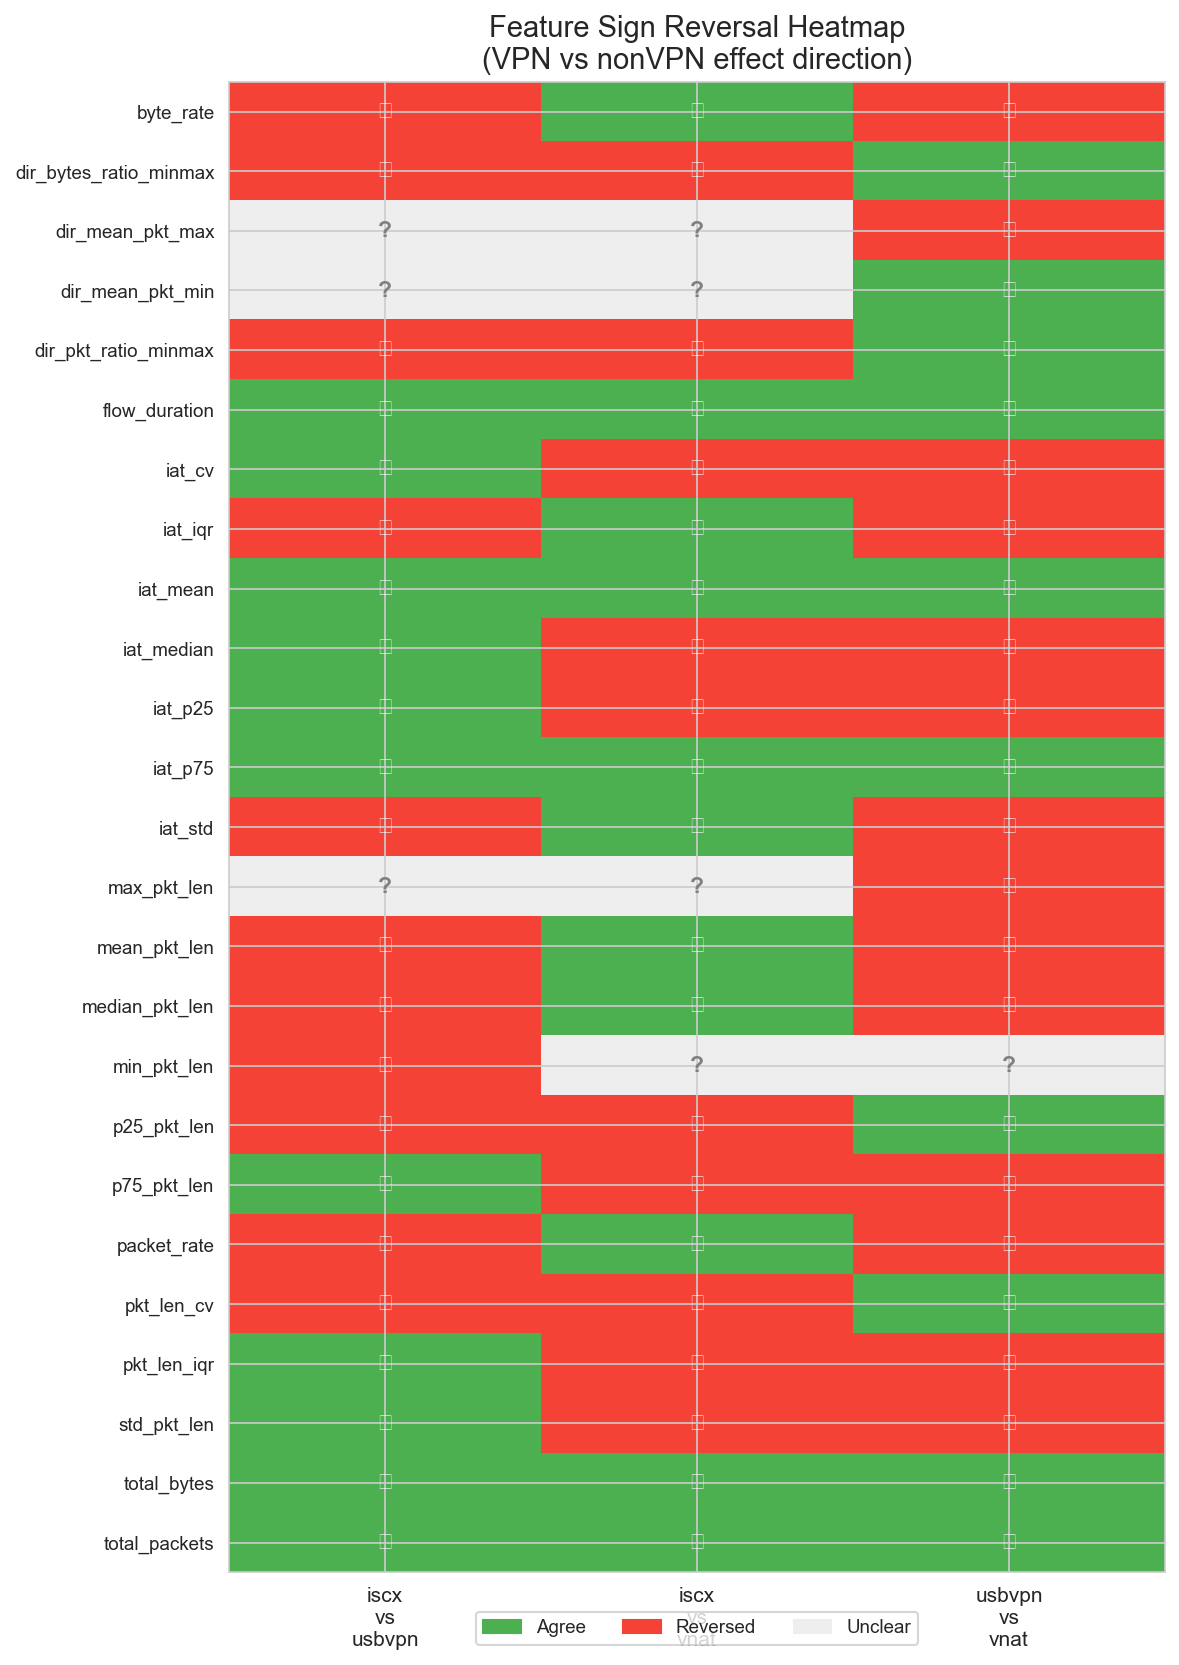


---
### 🖼 {_p.stem.replace("_", " ").title()}

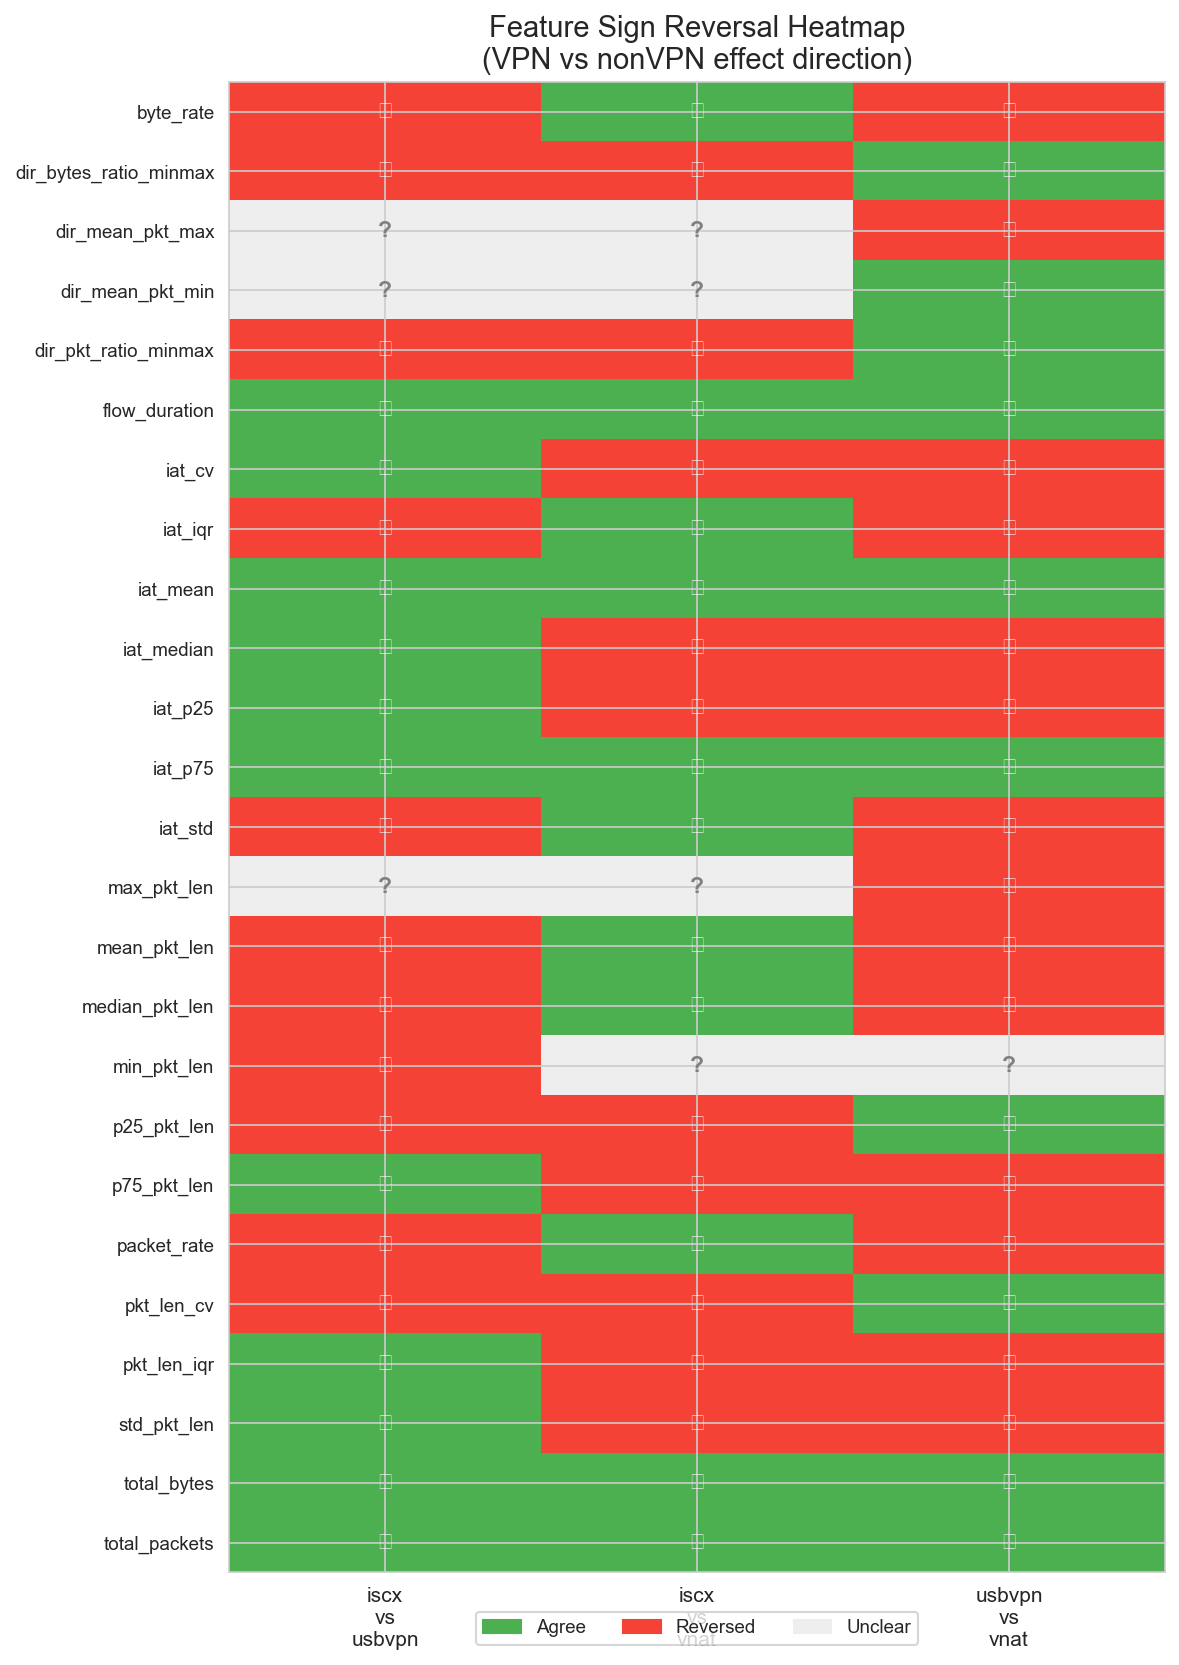


---
### 🖼 {_p.stem.replace("_", " ").title()}

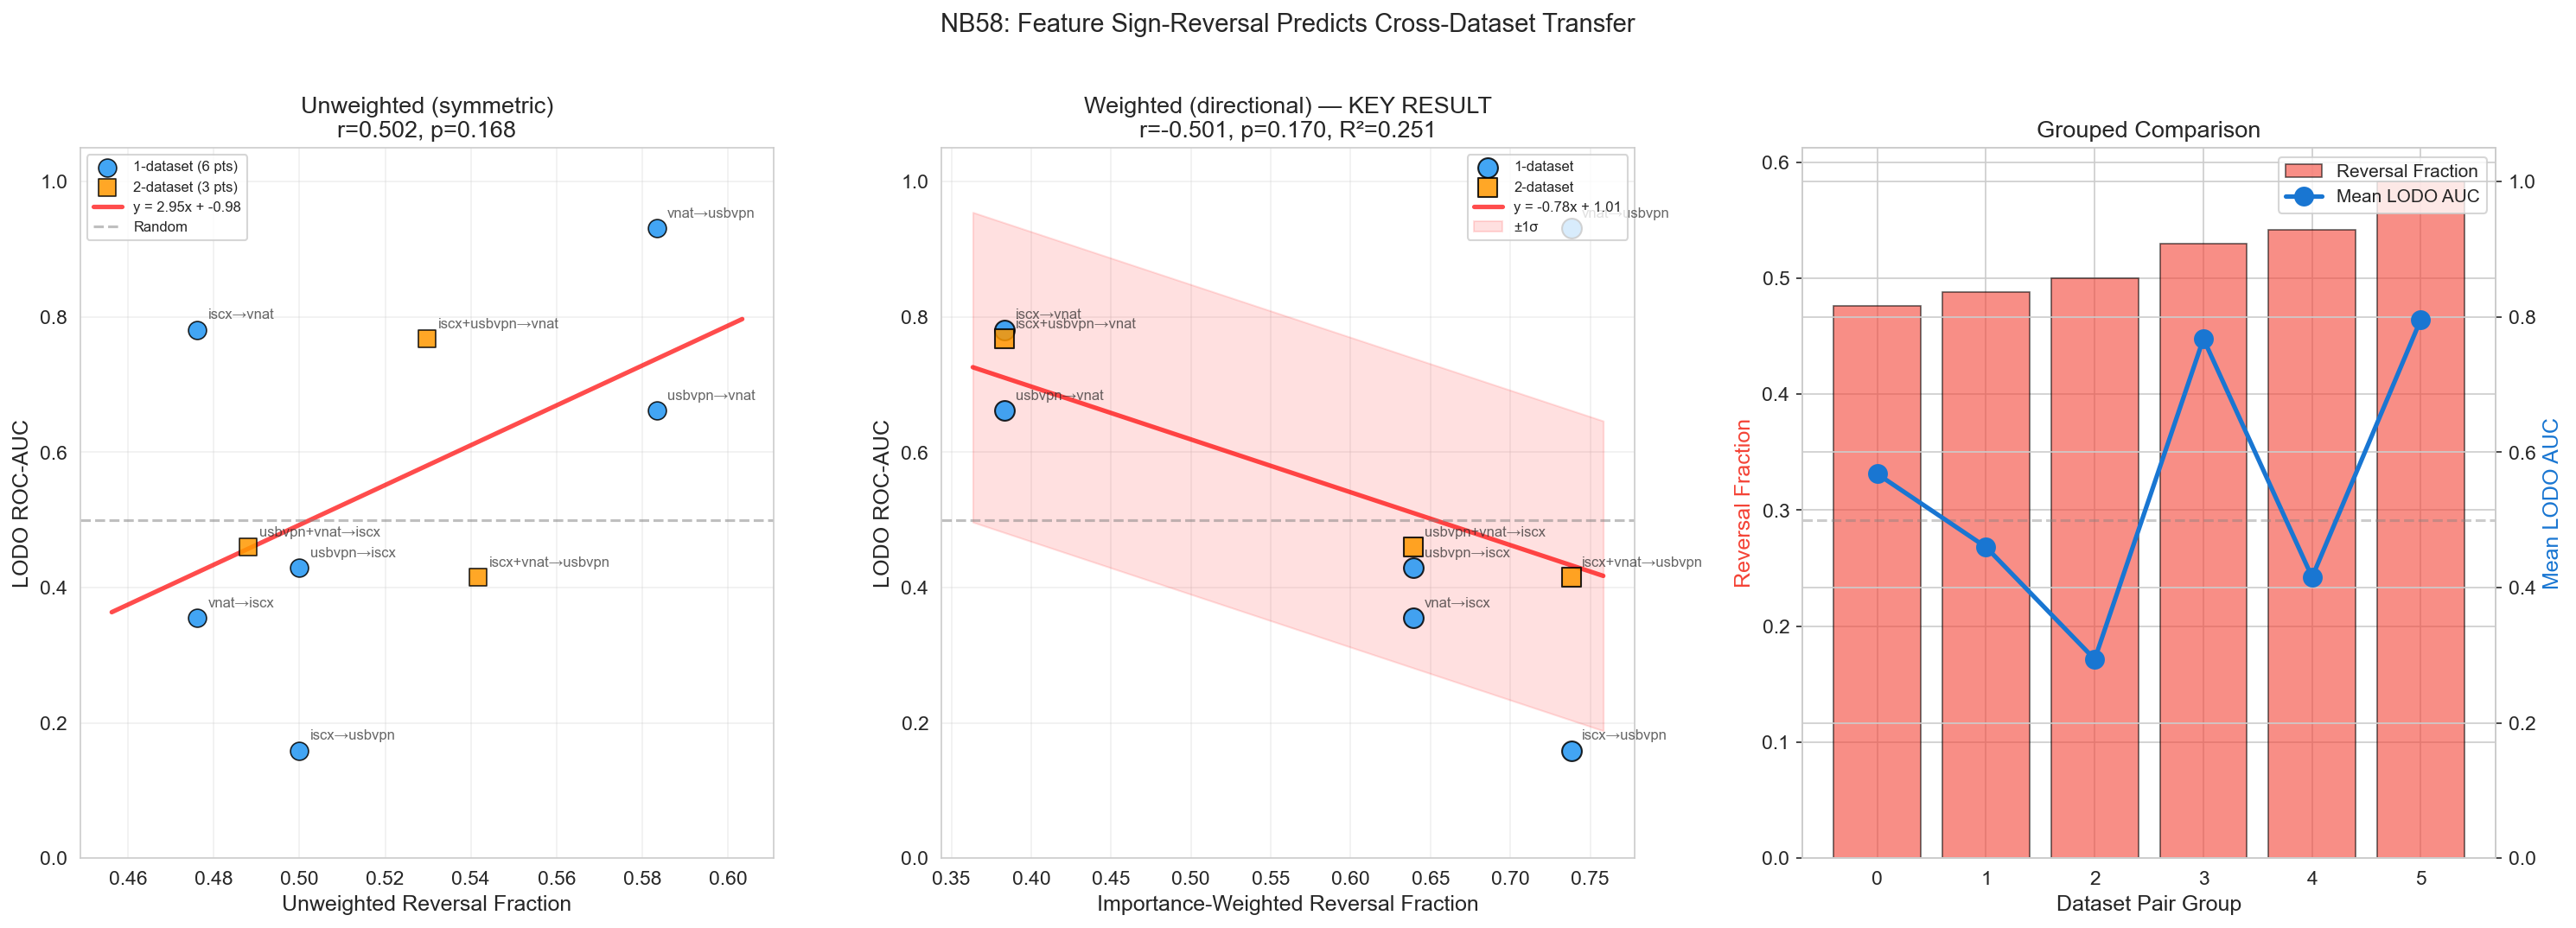


---
### 🖼 {_p.stem.replace("_", " ").title()}

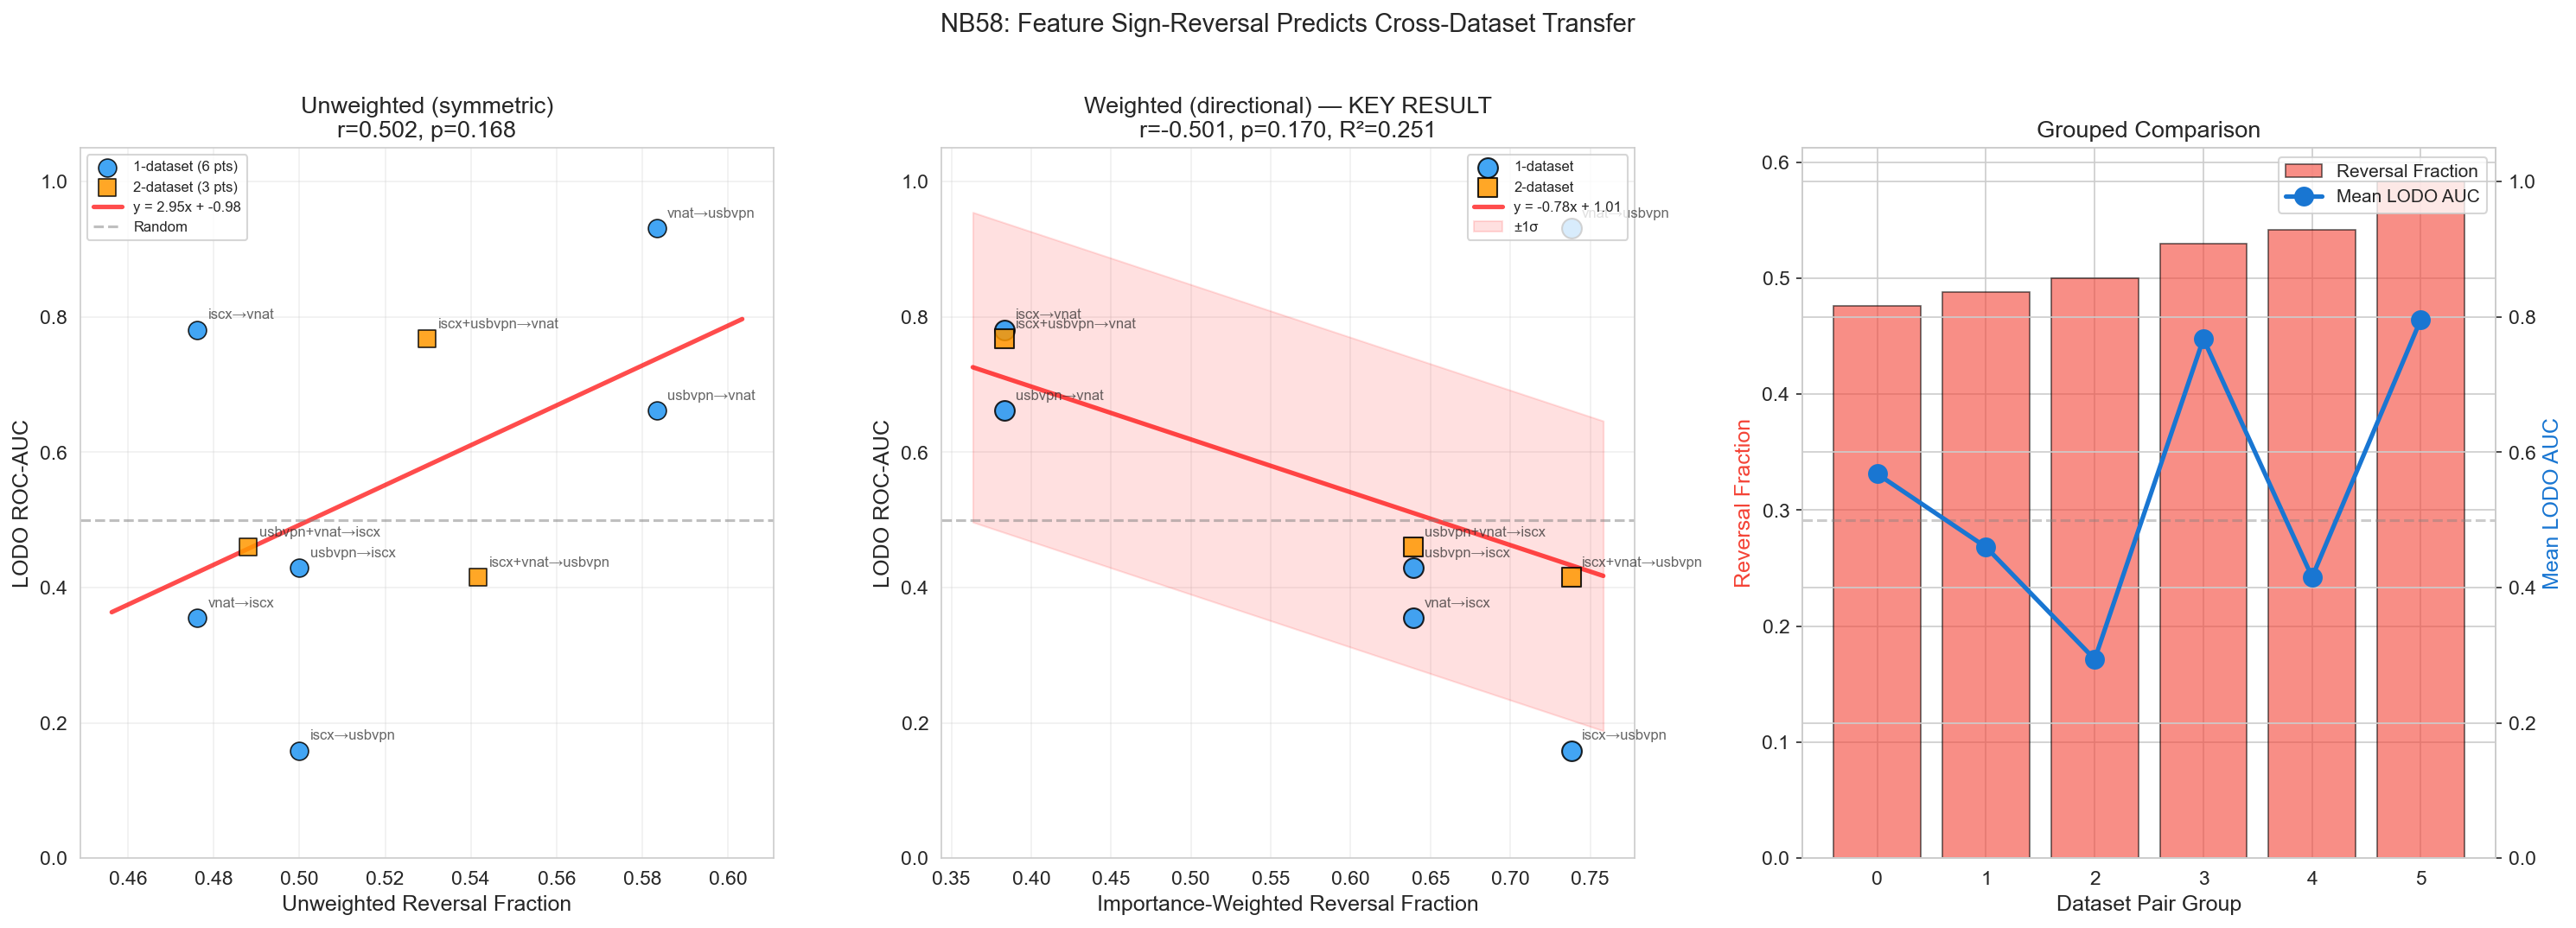


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,feature,iscx,usbvpn,vnat
0,byte_rate,-1,1,-1
1,dir_bytes_ratio_minmax,1,-1,-1
2,dir_mean_pkt_max,0,1,-1
3,dir_mean_pkt_min,0,-1,-1
4,dir_pkt_ratio_minmax,1,-1,-1
5,flow_duration,-1,-1,-1
6,iat_cv,1,1,-1
7,iat_iqr,-1,1,-1
8,iat_mean,-1,-1,-1
9,iat_median,-1,-1,1


### {_c.stem.replace("_", " ").title()}

,train,test,pair,reversal_fraction,lodo_auc,n_train_flows,transfer_type,weighted_reversal_fraction,unweighted_pearson_r,unweighted_pearson_p,unweighted_slope,unweighted_r2,weighted_pearson_r,weighted_pearson_p,weighted_slope,weighted_r2
0,iscx,usbvpn,iscx→usbvpn,0.5000,0.1590,8260,1-dataset,0.7382,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
1,usbvpn,iscx,usbvpn→iscx,0.5000,0.4289,40122,1-dataset,0.6393,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
2,iscx,vnat,iscx→vnat,0.4762,0.7808,8260,1-dataset,0.3834,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
3,vnat,iscx,vnat→iscx,0.4762,0.3550,5675,1-dataset,0.6393,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
4,usbvpn,vnat,usbvpn→vnat,0.5833,0.6615,40122,1-dataset,0.3834,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
5,vnat,usbvpn,vnat→usbvpn,0.5833,0.9309,5675,1-dataset,0.7382,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
6,iscx+usbvpn,vnat,iscx+usbvpn→vnat,0.5298,0.7677,58413,2-dataset,0.3834,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
7,iscx+vnat,usbvpn,iscx+vnat→usbvpn,0.5417,0.4153,13935,2-dataset,0.7382,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506
8,usbvpn+vnat,iscx,usbvpn+vnat→iscx,0.4881,0.4598,55828,2-dataset,0.6393,0.5021,0.1684,2.9451,0.2521,-0.5006,0.1699,-0.7815,0.2506



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB62",
  "title": "Dataset Scaling Law for Transfer",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_seeds": 3,
  "n_features": 21,
  "scaling_law": [
    {
      "datasets_used": 1,
      "transfer_auc_mean": 0.5113053907590712,
      "transfer_auc_std": 0.26913221057445286,
      "transfer_auc_min": 0.14165340330633205,
      "transfer_auc_max": 0.9006769966416175,
      "domain_auc": NaN,
      "n_evaluations": 18,
      "mean_train_flows": 20820
    },
    {
      "datasets_used": 2,
      "transfer_auc_mean": 0.5468154188256515,
      "transfer_auc_std": 0.16533461887471967,
      "transfer_auc_min": 0.3838519039157808,
      "transfer_auc_max": 0.7736556503795456,
      "domain_auc": 0.9998032553208515,
      "n_evaluations": 9,
      "mean_train_flows": 41640
    },
    {
      "datasets_used": 3,
      "transfer_auc_mean": 0.9956435308311173,
      "transfer_auc_std": 0.0021602940117162925,
      "transfer_auc_min": 0.9925446563729943,
      "transfer_auc_max": 0.9983727034120735,
      "domain_auc": 0.9997459737645702,
      "n_evaluations": 9,
      "mean_train_flows": 62461
    }
  ],
  "domain_classifier_aucs": {
    "iscx": NaN,
    "usbvpn": NaN,
    "vnat": NaN,
    "iscx+usbvpn": 0.9997,
    "iscx+vnat": 0.9998,
    "usbvpn+vnat": 0.9999,
    "iscx+usbvpn+vnat": 0.9997
  },
  "elapsed_seconds": 693.4
}
```


---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB60",
  "title": "Synthetic Deployment Robustness Simulation",
  "n_features": 21,
  "feature_set": [
    "total_packets",
    "total_bytes",
    "mean_pkt_len",
    "std_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "p75_pkt_len",
    "iat_mean",
    "iat_std",
    "iat_median",
    "flow_duration",
    "packet_rate",
    "byte_rate",
    "max_pkt_len",
    "min_pkt_len",
    "iat_cv",
    "iat_p25",
    "iat_p75",
    "iat_iqr",
    "pkt_len_cv",
    "pkt_len_iqr"
  ],
  "n_test_flows": 5203,
  "baseline_auc": 0.9981794911470054,
  "threshold": 0.5276475665891759,
  "models": [
    "xgb",
    "lgb",
    "cb"
  ],
  "perturbations": {
    "latency \u00d71.2": {
      "type": "latency_inflation",
      "strength": 1.2,
      "mean_prob_drift": 0.019396809399195768,
      "threshold_crossing_rate": 0.003843936190659235,
      "fp_inflation": 0.0038192234245703373,
      "auc_delta": -0.0001343491985836831
    },
    "latency \u00d71.5": {
      "type": "latency_inflation",
      "strength": 1.5,
      "mean_prob_drift": 0.0380998253041461,
      "threshold_crossing_rate": 0.013261579857774361,
      "fp_inflation": 0.01718650541056652,
      "auc_delta": -0.001102589974584789
    },
    "latency \u00d72.0": {
      "type": "latency_inflation",
      "strength": 2.0,
      "mean_prob_drift": 0.06079975526533983,
      "threshold_crossing_rate": 0.02940611185854315,
      "fp_inflation": 0.040420114576702734,
      "auc_delta": -0.003365833485441394
    },
    "trunc 50%": {
      "type": "packet_truncation",
      "strength": 0.5,
      "mean_prob_drift": 0.12309005022146684,
      "threshold_crossing_rate": 0.0939842398616183,
      "fp_inflation": 0.028644175684277528,
      "auc_delta": -0.03363100174159794
    },
    "trunc 75%": {
      "type": "packet_truncation",
      "strength": 0.25,
      "mean_prob_drift": 0.08707873407266772,
      "threshold_crossing_rate": 0.035172016144532,
      "fp_inflation": 0.027689369828134944,
      "auc_delta": -0.01604299297894174
    },
    "length \u00d70.8": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.04534924674036569,
      "threshold_crossing_rate": 0.0048049202383240435,
      "fp_inflation": -0.001591343093570976,
      "auc_delta": -0.0017094777337048894
    },
    "length \u00d71.2": {
      "type": "flow_length_scaling",
      "strength": 0.19999999999999996,
      "mean_prob_drift": 0.0114067963444852,
      "threshold_crossing_rate": 0.004228329809725159,
      "fp_inflation": -0.0012730744748567814,
      "auc_delta": -0.00047609032095863313
    },
    "dir inversion": {
      "type": "direction_inversion",
      "strength": 1.0,
      "mean_prob_drift": 0.0,
      "threshold_crossing_rate": 0.0,
      "fp_inflation": 0.0,
      "auc_delta": 0.0
    },
    "burst \u03c3=0.05": {
      "type": "burst_reshaping",
      "strength": 0.05,
      "mean_prob_drift": 0.10335347673922901,
      "threshold_crossing_r
```


✅ NB58 gallery complete.


In [1]:
# ── Results Gallery: NB58 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "conference_eval"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

_prefix = 'sign_reversal_transfer'
_pngs = [p for p in _pngs if _prefix in p.stem.lower() or 'sign_rev' in p.stem.lower()]
_csvs = [p for p in _csvs if _prefix in p.stem.lower() or 'sign_rev' in p.stem.lower()]

display(Markdown(f'# \U0001f4ca NB58 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB58 gallery complete.')
